In [1]:
# Install required packages
%pip install pandas numpy matplotlib seaborn scikit-learn scipy --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the required library
import pandas as pd

# Load the dataset
df = pd.read_csv("../dataset/Telco-Customer-Churn.csv")

# Display the first five rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

Dataset Shape: (7043, 21)


In [4]:
# Display column names
print(df.columns.tolist())

# Display data types and non-null counts
df.info()


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBacku

In [5]:
# Generate descriptive statistics
df.describe(include="all")


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
# Check missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [7]:
# Check blank or whitespace-only values

for col in df.select_dtypes(include="object").columns:
    blank_count = df[col].str.strip().eq("").sum()
    if blank_count > 0:
        print(f"{col}: {blank_count} blank values")

TotalCharges: 11 blank values


C:\Users\vsing\AppData\Local\Temp\ipykernel_12920\3621494305.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [8]:
# Display the first 10 values of TotalCharges

print(df["TotalCharges"].head(10))

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str


In [9]:
# Identify whitespace-only entries

blank_total_charges = df[
    df["TotalCharges"].str.strip() == ""
]

print("Blank TotalCharges records:", len(blank_total_charges))

blank_total_charges.head()

Blank TotalCharges records: 11


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


In [10]:
# Check duplicate records

print("Duplicate rows:", df.duplicated().sum())

# Check duplicate customer IDs

print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [11]:
# Count customers in each churn category

print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [12]:
# Calculate churn percentages

churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [13]:
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [14]:
for col in df.select_dtypes(include="object").columns:
    blank_count = df[col].str.strip().eq("").sum()
    if blank_count > 0:
        print(f"{col}: {blank_count} blank values")

TotalCharges: 11 blank values


C:\Users\vsing\AppData\Local\Temp\ipykernel_12920\1680637096.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [15]:
# Display the first 10 TotalCharges values
print(df["TotalCharges"].head(10))

# Identify records with blank TotalCharges
blank_total_charges = df[
    df["TotalCharges"].str.strip() == ""
]

# Display the number of affected records
print("Blank TotalCharges records:", len(blank_total_charges))

# Display the affected customer records
blank_total_charges[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str
Blank TotalCharges records: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


In [16]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check duplicate customer IDs
print("Duplicate customer IDs:", df["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [17]:
# Count customers in each churn category
print(df["Churn"].value_counts())


Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [18]:
# Calculate churn percentages
churn_percentage = df["Churn"].value_counts(normalize=True) * 100

print(churn_percentage.round(2))

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [19]:
# Create a copy of the original dataset
df_clean = df.copy()

# Verify the copy
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)


Original dataset shape: (7043, 21)
Cleaned dataset shape: (7043, 21)


In [20]:
# Replace whitespace-only values with NaN
df_clean["TotalCharges"] = df_clean["TotalCharges"].str.strip()

df_clean["TotalCharges"] = df_clean["TotalCharges"].replace("", pd.NA)

# Convert TotalCharges into a numeric column
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Replace missing TotalCharges with 0 for zero-tenure customers
df_clean.loc[
    (df_clean["tenure"] == 0) & (df_clean["TotalCharges"].isna()),
    "TotalCharges"
] = 0

# Check the results
print("Missing TotalCharges:", df_clean["TotalCharges"].isna().sum())
print("TotalCharges data type:", df_clean["TotalCharges"].dtype)

Missing TotalCharges: 0
TotalCharges data type: float64


In [21]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [24]:
print("Seaborn version:", sns.__version__)


Seaborn version: 0.13.2


In [25]:
# Create a copy of the original dataset
df_clean = df.copy()

# Verify the copy
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", df_clean.shape)


Original dataset shape: (7043, 21)
Cleaned dataset shape: (7043, 21)


In [26]:
# Replace whitespace-only values with NaN
df_clean["TotalCharges"] = df_clean["TotalCharges"].str.strip()

df_clean["TotalCharges"] = df_clean["TotalCharges"].replace("", pd.NA)

# Convert TotalCharges into a numeric column
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Replace missing TotalCharges with 0 for zero-tenure customers
df_clean.loc[
    (df_clean["tenure"] == 0) & (df_clean["TotalCharges"].isna()),
    "TotalCharges"
] = 0

# Check the results
print("Missing TotalCharges:", df_clean["TotalCharges"].isna().sum())
print("TotalCharges data type:", df_clean["TotalCharges"].dtype)

Missing TotalCharges: 0
TotalCharges data type: float64


In [27]:
print(df_clean["TotalCharges"].dtype)

float64


In [28]:
# Convert TotalCharges to numeric
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

# Replace missing values with 0 for customers with zero tenure
df_clean.loc[
    (df_clean["tenure"] == 0) & (df_clean["TotalCharges"].isna()),
    "TotalCharges"
] = 0

# Verify the results
print("Missing TotalCharges:", df_clean["TotalCharges"].isna().sum())
print("Data type:", df_clean["TotalCharges"].dtype)

Missing TotalCharges: 0
Data type: float64


In [29]:
print("Missing values:", df_clean["TotalCharges"].isna().sum())
print("Data type:", df_clean["TotalCharges"].dtype)

Missing values: 0
Data type: float64


In [30]:
# Verify TotalCharges cleaning

print("Missing values:", df_clean["TotalCharges"].isna().sum())
print("Data type:", df_clean["TotalCharges"].dtype)

Missing values: 0
Data type: float64


In [31]:
# Check the cleaned dataset
print("Dataset shape:", df_clean.shape)
print("\nMissing values in each column:")
print(df_clean.isnull().sum())

Dataset shape: (7043, 21)

Missing values in each column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [32]:
# Check unique values in categorical columns
categorical_cols = df_clean.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}:")
    print(df_clean[col].value_counts())


customerID:
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64

gender:
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner:
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents:
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService:
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines:
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService:
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity:
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup:
OnlineBackup
No                     3088
Yes                

C:\Users\vsing\AppData\Local\Temp\ipykernel_12920\2495009181.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df_clean.select_dtypes(include="object").columns


In [33]:
# Display unique values in each categorical column
for col in df_clean.select_dtypes(include="object").columns:
    print(f"{col}: {df_clean[col].unique()}")

customerID: <StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str
gender: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService: <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines: <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService: <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity: <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup: <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection: <StringArray>
['No', 'Yes', 'No internet service']


C:\Users\vsing\AppData\Local\Temp\ipykernel_12920\3632131390.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include="object").columns:


In [34]:
# Summary statistics for numerical columns
df_clean[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


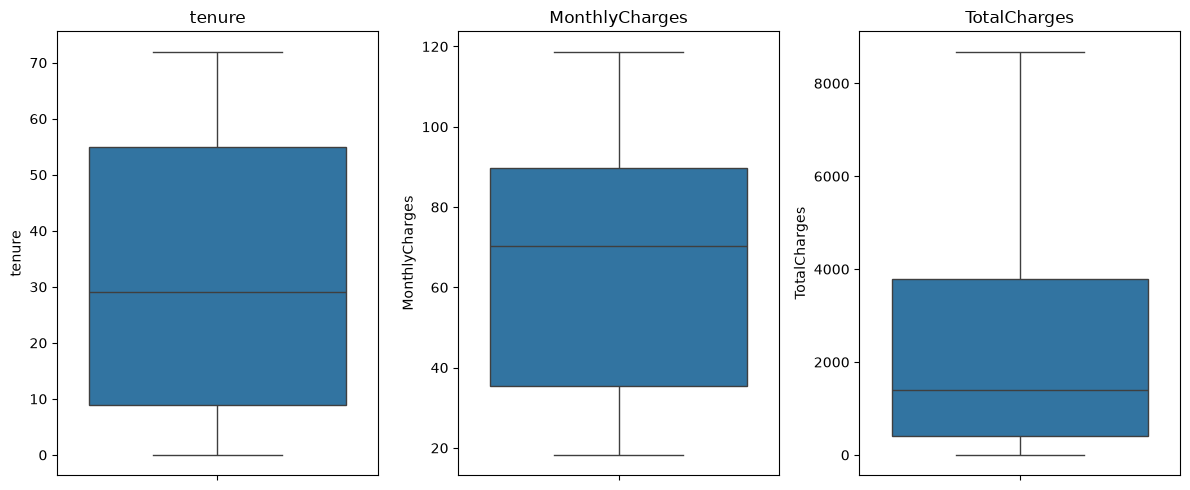

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(12, 5))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_clean[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [36]:
# Final data-cleaning verification

print("Dataset shape:", df_clean.shape)
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate customer IDs:", df_clean["customerID"].duplicated().sum())
print("Missing values:", df_clean.isnull().sum().sum())
print("\nData types:")
print(df_clean.dtypes)

Dataset shape: (7043, 21)
Duplicate rows: 0
Duplicate customer IDs: 0
Missing values: 0

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object


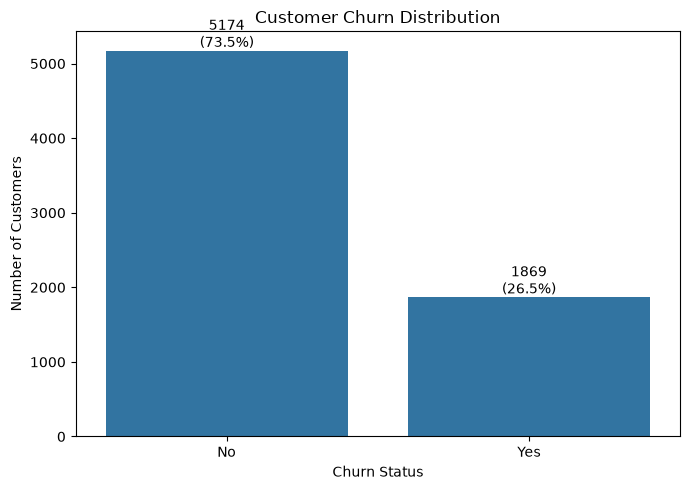

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count customers by churn status
churn_counts = df_clean["Churn"].value_counts()

# Create a bar chart
plt.figure(figsize=(7, 5))
sns.countplot(data=df_clean, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

# Display count and percentage above each bar
for i, count in enumerate(churn_counts):
    percentage = count / len(df_clean) * 100
    plt.text(i, count + 50, f"{count}\n({percentage:.1f}%)",
             ha="center")

plt.tight_layout()
plt.show()

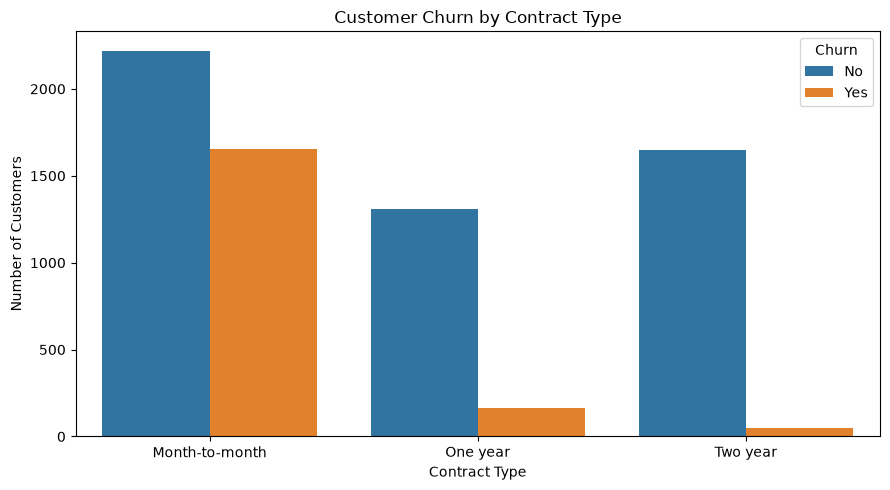

In [38]:
# Analyze churn by contract type

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")

plt.tight_layout()
plt.show()

In [39]:
# Calculate churn rate by contract type
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn = contract_churn.round(2)

print(contract_churn)

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.73  11.27
Two year        97.17   2.83


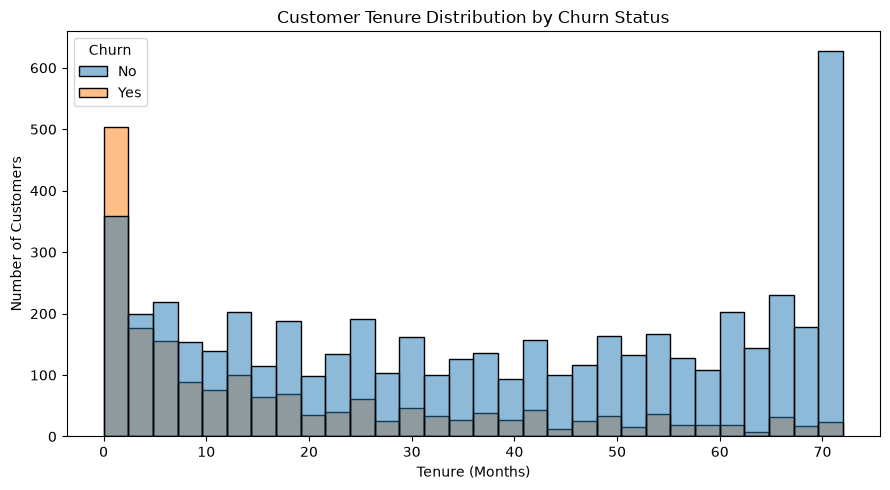

In [40]:
# Compare customer tenure by churn status

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    bins=30,
    multiple="layer",
    kde=False
)

plt.title("Customer Tenure Distribution by Churn Status")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [41]:
# Group customers by tenure
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

# Calculate churn rate for each tenure group
tenure_churn = pd.crosstab(
    df_clean["TenureGroup"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(tenure_churn.round(2))

Churn            No    Yes
TenureGroup               
0-12 months   52.56  47.44
13-24 months  71.29  28.71
25-48 months  79.61  20.39
49-72 months  90.49   9.51


In [42]:
# Analyze churn by payment method

payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
) * 100

payment_churn = payment_churn.round(2)

print(payment_churn)

Churn                         No    Yes
PaymentMethod                          
Bank transfer (automatic)  83.29  16.71
Credit card (automatic)    84.76  15.24
Electronic check           54.71  45.29
Mailed check               80.89  19.11


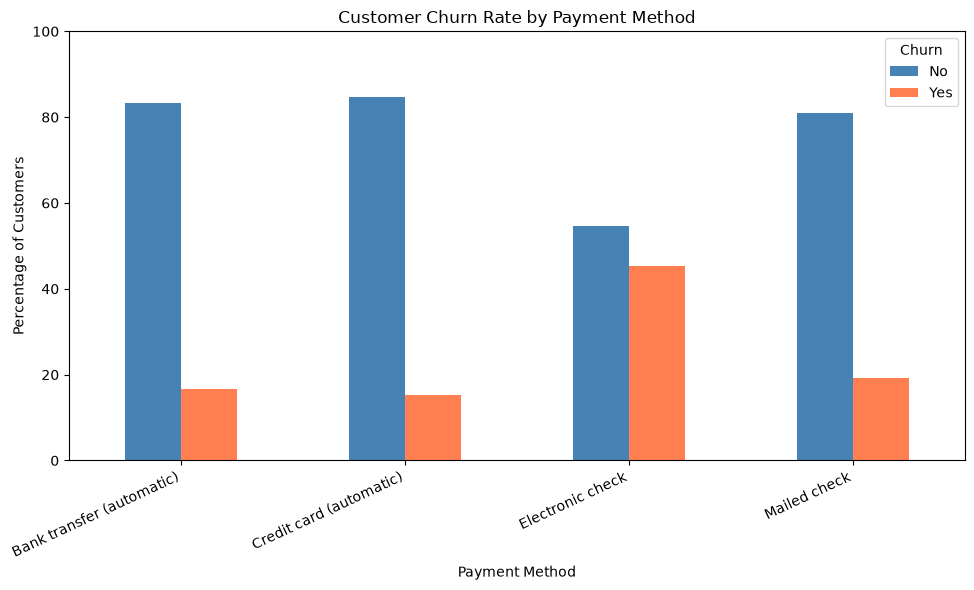

In [43]:
# Visualize churn rate by payment method

payment_churn.plot(
    kind="bar",
    figsize=(10, 6),
    color=["steelblue", "coral"]
)

plt.title("Customer Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Churn")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

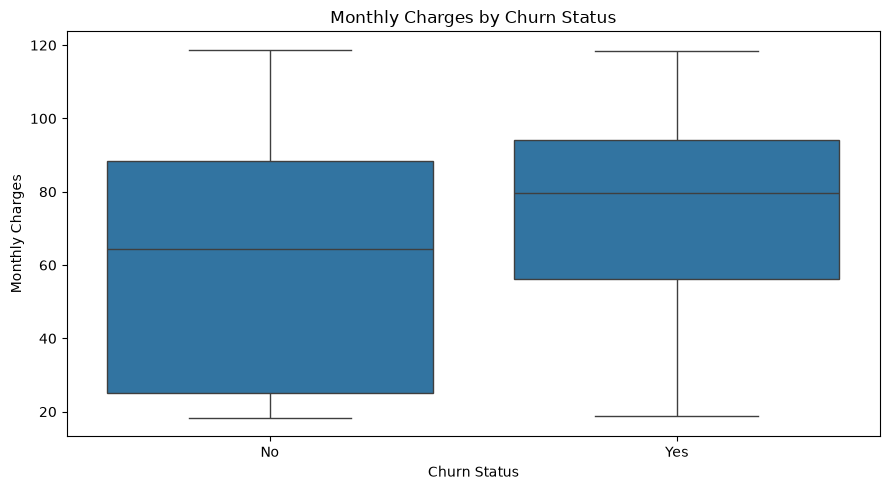

In [44]:
# Compare monthly charges by churn status

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

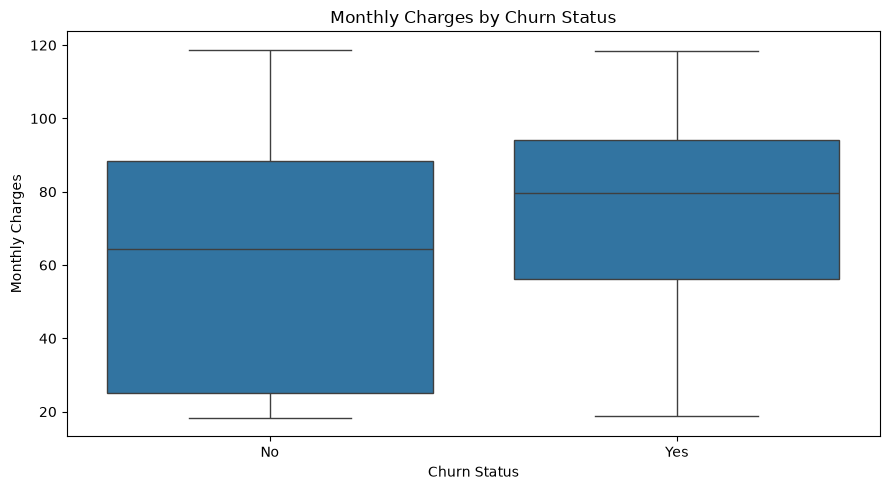

In [45]:
# Compare monthly charges by churn status

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

In [46]:
# Calculate churn rate by internet service

internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(internet_churn.round(2))


Churn               No    Yes
InternetService              
DSL              81.04  18.96
Fiber optic      58.11  41.89
No               92.60   7.40


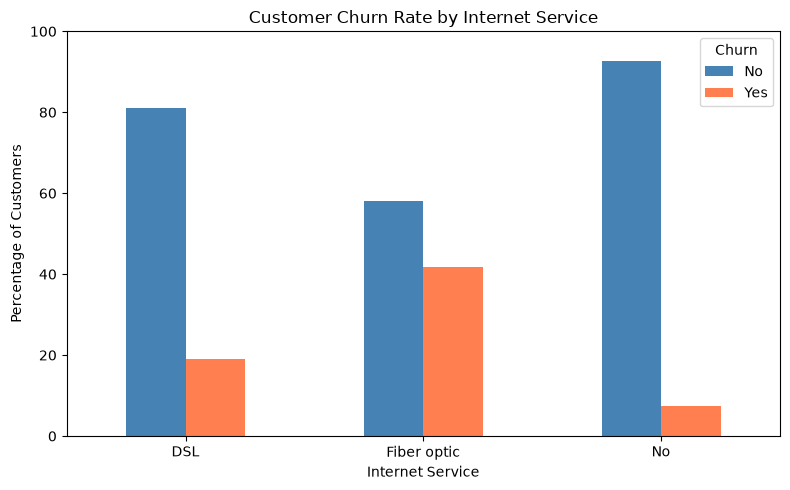

In [47]:
# Visualize churn rate by internet service

internet_churn.plot(
    kind="bar",
    figsize=(8, 5),
    color=["steelblue", "coral"]
)

plt.title("Customer Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [48]:
# Calculate churn rate by online security subscription

security_churn = pd.crosstab(
    df_clean["OnlineSecurity"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(security_churn.round(2))

Churn                   No    Yes
OnlineSecurity                   
No                   58.23  41.77
No internet service  92.60   7.40
Yes                  85.39  14.61


In [49]:
# Calculate churn rate by tech support subscription

support_churn = pd.crosstab(
    df_clean["TechSupport"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(support_churn.round(2))

Churn                   No    Yes
TechSupport                      
No                   58.36  41.64
No internet service  92.60   7.40
Yes                  84.83  15.17


In [50]:
# Compare churn rates across additional services

service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

service_churn_rates = {}

for col in service_cols:
    rates = pd.crosstab(
        df_clean[col],
        df_clean["Churn"],
        normalize="index"
    ) * 100

    service_churn_rates[col] = rates["Yes"].get("Yes", 0)

service_churn_df = pd.DataFrame(
    service_churn_rates,
    index=["Churn Rate"]
).T

print(service_churn_df.round(2))

                  Churn Rate
OnlineSecurity         14.61
OnlineBackup           21.53
DeviceProtection       22.50
TechSupport            15.17
StreamingTV            30.07
StreamingMovies        29.94


In [51]:
# Compare churn rates for subscribers and non-subscribers

service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

for col in service_cols:
    print(f"\n{col}")

    rates = pd.crosstab(
        df_clean[col],
        df_clean["Churn"],
        normalize="index"
    ) * 100

    print(rates[["Yes"]].round(2))


OnlineSecurity
Churn                  Yes
OnlineSecurity            
No                   41.77
No internet service   7.40
Yes                  14.61

OnlineBackup
Churn                  Yes
OnlineBackup              
No                   39.93
No internet service   7.40
Yes                  21.53

DeviceProtection
Churn                  Yes
DeviceProtection          
No                   39.13
No internet service   7.40
Yes                  22.50

TechSupport
Churn                  Yes
TechSupport               
No                   41.64
No internet service   7.40
Yes                  15.17

StreamingTV
Churn                  Yes
StreamingTV               
No                   33.52
No internet service   7.40
Yes                  30.07

StreamingMovies
Churn                  Yes
StreamingMovies           
No                   33.68
No internet service   7.40
Yes                  29.94


In [52]:
# Compare churn rates for customers with and without each service

service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

comparison = {}

for col in service_cols:
    rates = pd.crosstab(
        df_clean[col],
        df_clean["Churn"],
        normalize="index"
    ) * 100

    comparison[col] = {
        "Without service (%)": rates.loc["No", "Yes"],
        "With service (%)": rates.loc["Yes", "Yes"]
    }

comparison_df = pd.DataFrame(comparison).T.round(2)

print(comparison_df)

                  Without service (%)  With service (%)
OnlineSecurity                  41.77             14.61
OnlineBackup                    39.93             21.53
DeviceProtection                39.13             22.50
TechSupport                     41.64             15.17
StreamingTV                     33.52             30.07
StreamingMovies                 33.68             29.94


In [53]:
# Consolidated EDA summary

eda_summary = pd.DataFrame({
    "Factor": [
        "Month-to-month contract",
        "0-12 months tenure",
        "Electronic check",
        "Fiber optic internet",
        "No online security",
        "No tech support"
    ],
    "Churn Rate (%)": [
        42.71,
        47.44,
        45.29,
        41.89,
        41.77,
        41.64
    ]
})

print(eda_summary)

                    Factor  Churn Rate (%)
0  Month-to-month contract           42.71
1       0-12 months tenure           47.44
2         Electronic check           45.29
3     Fiber optic internet           41.89
4       No online security           41.77
5          No tech support           41.64


In [54]:
# Create a copy for machine learning
model_df = df_clean.copy()

# Remove customer ID
model_df = model_df.drop(columns=["customerID"])

# Check the updated dataset
print("Original cleaned dataset:", df_clean.shape)
print("Modeling dataset:", model_df.shape)

model_df.head()

Original cleaned dataset: (7043, 22)
Modeling dataset: (7043, 21)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 months
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 months
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 months
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 months
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 months


In [55]:
# Remove the analysis-only tenure group
model_df = model_df.drop(columns=["TenureGroup"])

# Convert churn into numerical values
model_df["Churn"] = model_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

# Verify the conversion
print("Churn values:")
print(model_df["Churn"].value_counts())

print("\nData types:")
print(model_df["Churn"].dtype)

print("\nDataset shape:", model_df.shape)

Churn values:
Churn
0    5174
1    1869
Name: count, dtype: int64

Data types:
int64

Dataset shape: (7043, 20)


In [56]:
# Separate input features and target variable
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

# Verify the separation
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Features shape: (7043, 19)
Target shape: (7043,)

Target distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [57]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Verify the split
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training features: (5634, 19)
Testing features: (1409, 19)

Training target distribution:
Churn
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn
0    1035
1     374
Name: count, dtype: int64


In [58]:
# Identify categorical and numerical columns
categorical_cols = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumber of categorical columns:", len(categorical_cols))

print("\nNumerical columns:", numerical_cols)
print("\nNumber of numerical columns:", len(numerical_cols))

Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of categorical columns: 15

Numerical columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Number of numerical columns: 4


C:\Users\vsing\AppData\Local\Temp\ipykernel_12920\2547277928.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X_train.select_dtypes(


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Create the preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numerical_cols)
    ]
)

# Fit on training data and transform both datasets
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

# Verify the results
print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

Encoded training shape: (5634, 45)
Encoded testing shape: (1409, 45)


In [60]:
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# Create the scaler
scaler = StandardScaler()

# Identify the positions of numerical features in the encoded matrix
num_indices = [
    i for i, feature in enumerate(preprocessor.get_feature_names_out())
    if feature.startswith("num__")
]

# Separate numerical and categorical encoded features
X_train_cat = X_train_encoded[:, [i for i in range(X_train_encoded.shape[1]) if i not in num_indices]]
X_test_cat = X_test_encoded[:, [i for i in range(X_test_encoded.shape[1]) if i not in num_indices]]

X_train_num = X_train_encoded[:, num_indices]
X_test_num = X_test_encoded[:, num_indices]

# Scale numerical features using training data only
X_train_num_scaled = scaler.fit_transform(X_train_num)
X_test_num_scaled = scaler.transform(X_test_num)

# Combine scaled numerical and categorical features
X_train_final = hstack([X_train_cat, csr_matrix(X_train_num_scaled)])
X_test_final = hstack([X_test_cat, csr_matrix(X_test_num_scaled)])

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (5634, 45)
Final testing shape: (1409, 45)


In [61]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
log_model.fit(X_train_final, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [62]:
# Predict customer churn on the test dataset
y_pred = log_model.predict(X_test_final)

# Display the first 10 predictions
print("First 10 predictions:", y_pred[:10])

# Display the corresponding actual values
print("Actual values:", y_test.iloc[:10].values)

First 10 predictions: [0 1 0 0 0 1 0 0 0 0]
Actual values: [0 0 0 0 0 0 0 0 0 1]


In [63]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display results
print("Model Evaluation Results")
print("-" * 30)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

Model Evaluation Results
------------------------------
Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1-Score:  0.6040

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



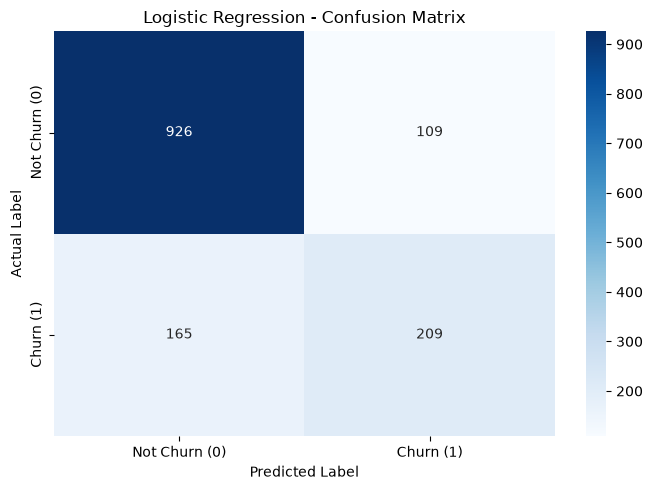

Confusion Matrix:
[[926 109]
 [165 209]]


In [64]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn (0)", "Churn (1)"],
    yticklabels=["Not Churn (0)", "Churn (1)"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

print("Confusion Matrix:")
print(cm)

In [65]:
import pandas as pd
import numpy as np

# Get encoded feature names
feature_names = preprocessor.get_feature_names_out()

# Get Logistic Regression coefficients
coefficients = log_model.coef_[0]

# Create a DataFrame of coefficients
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

# Sort by coefficient
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

# Display the 10 strongest positive coefficients
print("Top 10 features associated with higher churn predictions:")
print(feature_importance.head(10).to_string(index=False))

# Display the 10 strongest negative coefficients
print("\nTop 10 features associated with lower churn predictions:")
print(feature_importance.tail(10).sort_values(
    by="Coefficient"
).to_string(index=False))

Top 10 features associated with higher churn predictions:
                            Feature  Coefficient
   cat__InternetService_Fiber optic     0.634195
       cat__Contract_Month-to-month     0.582883
                  num__TotalCharges     0.536253
           cat__StreamingMovies_Yes     0.200938
               cat__StreamingTV_Yes     0.200481
cat__PaymentMethod_Electronic check     0.197867
             cat__OnlineSecurity_No     0.156279
                cat__TechSupport_No     0.131503
             cat__MultipleLines_Yes     0.104649
                 num__SeniorCitizen     0.053449

Top 10 features associated with lower churn predictions:
                                  Feature  Coefficient
                              num__tenure    -1.257539
                   cat__Contract_Two year    -0.776594
                 cat__InternetService_DSL    -0.648646
                      num__MonthlyCharges    -0.591863
                 cat__PaperlessBilling_No    -0.343227
cat__DeviceProt

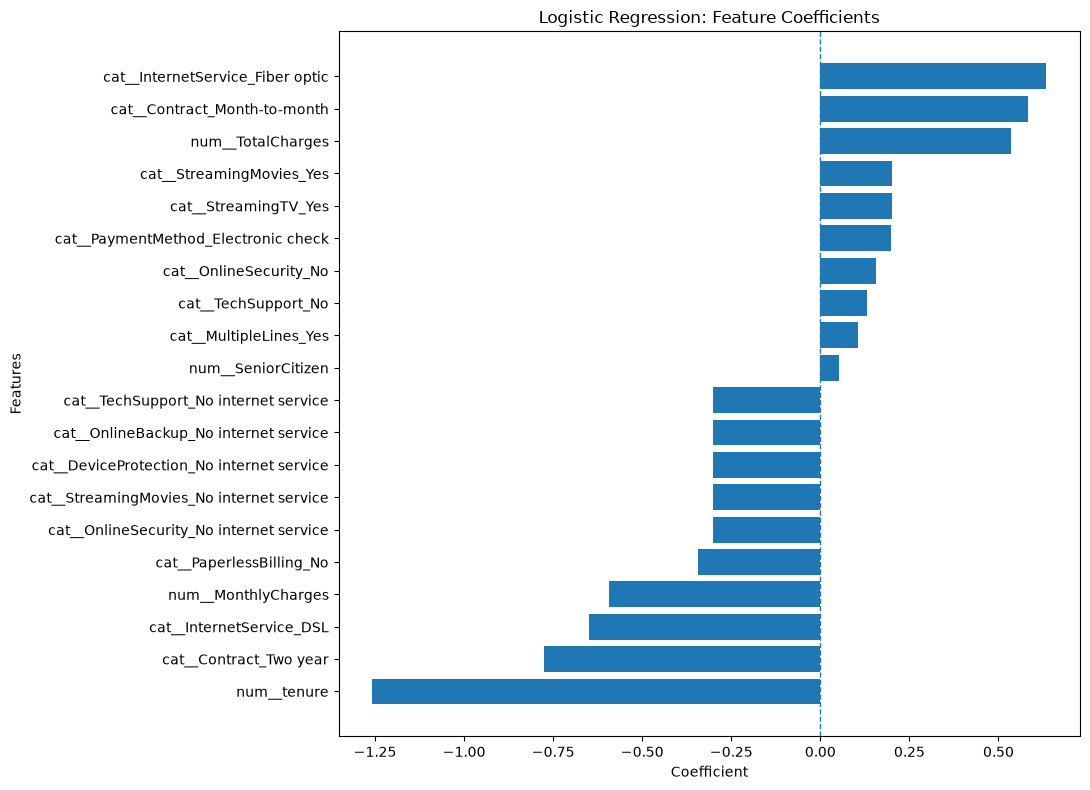

In [66]:
import matplotlib.pyplot as plt

# Select the 10 strongest positive and negative coefficients
top_positive = feature_importance.head(10)
top_negative = feature_importance.tail(10)

# Combine the selected features
selected_features = pd.concat([top_positive, top_negative])

# Sort coefficients for visualization
selected_features = selected_features.sort_values(
    by="Coefficient"
)

# Create the horizontal bar chart
plt.figure(figsize=(11, 8))

plt.barh(
    selected_features["Feature"],
    selected_features["Coefficient"]
)

plt.axvline(x=0, linestyle="--", linewidth=1)

plt.title("Logistic Regression: Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

In [67]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train_final, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [68]:
# Make predictions using the Random Forest model
y_pred_rf = rf_model.predict(X_test_final)

# Display the first 10 predictions
print("First 10 predictions:", y_pred_rf[:10])

# Display the corresponding actual values
print("Actual values:", y_test.iloc[:10].values)

First 10 predictions: [0 1 0 0 0 1 0 0 0 1]
Actual values: [0 0 0 0 0 0 0 0 0 1]


In [69]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

# Display results
print("Random Forest Evaluation Results")
print("-" * 35)
print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Evaluation Results
-----------------------------------
Accuracy:  0.7622
Precision: 0.5455
Recall:    0.6257
F1-Score:  0.5828

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.55      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409



              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.805536   0.657233 0.558824  0.604046
      Random Forest  0.762243   0.545455 0.625668  0.582814


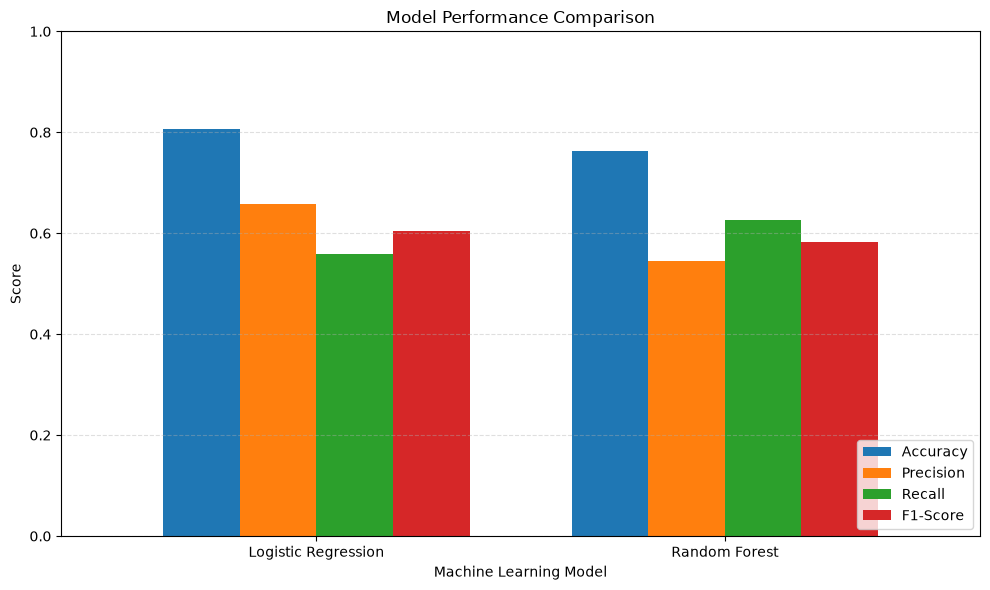

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a comparison DataFrame
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, accuracy_rf],
    "Precision": [precision, precision_rf],
    "Recall": [recall, recall_rf],
    "F1-Score": [f1, f1_rf]
})

# Display comparison table
print(comparison.to_string(index=False))

# Plot comparison
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6),
    width=0.75
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [71]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd

# Get churn probabilities from Logistic Regression
y_prob = log_model.predict_proba(X_test_final)[:, 1]

# Test different probability thresholds
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

results = []

for threshold in thresholds:
    y_threshold_pred = (y_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_threshold_pred),
        "Recall": recall_score(y_test, y_threshold_pred),
        "F1-Score": f1_score(y_test, y_threshold_pred)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.round(4).to_string(index=False))

 Threshold  Precision  Recall  F1-Score
      0.30     0.5193  0.7540    0.6150
      0.35     0.5432  0.7059    0.6140
      0.40     0.5682  0.6684    0.6143
      0.45     0.6021  0.6150    0.6085
      0.50     0.6572  0.5588    0.6040
      0.55     0.6784  0.4626    0.5501
      0.60     0.7177  0.4011    0.5146


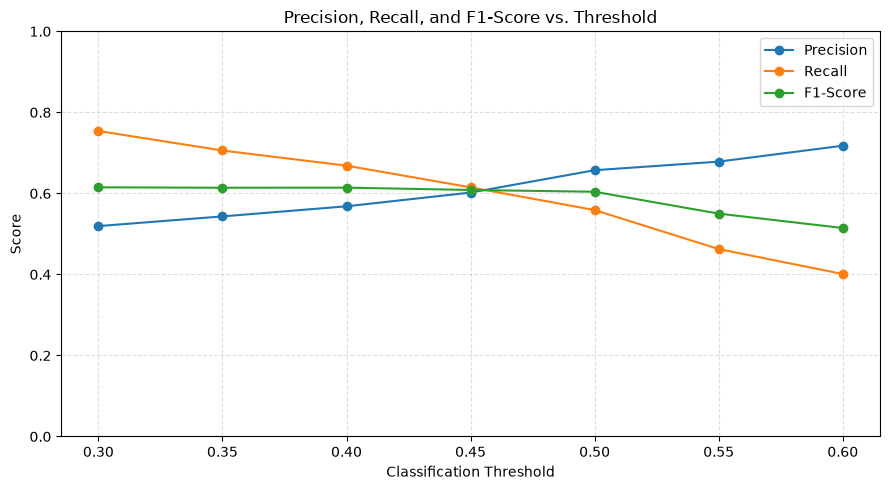

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.title("Precision, Recall, and F1-Score vs. Threshold")
plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.xticks(thresholds)
plt.ylim(0, 1)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [73]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np

# Define stratified cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate out-of-fold churn probabilities
oof_prob = cross_val_predict(
    clone(log_model),
    X_train_final,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Evaluate candidate thresholds using training predictions
candidate_thresholds = np.arange(0.20, 0.61, 0.05)

threshold_cv_results = []

for threshold in candidate_thresholds:
    oof_pred = (oof_prob >= threshold).astype(int)

    threshold_cv_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(y_train, oof_pred),
        "Recall": recall_score(y_train, oof_pred),
        "F1-Score": f1_score(y_train, oof_pred)
    })

threshold_cv_results = pd.DataFrame(threshold_cv_results)

print(threshold_cv_results.round(4).to_string(index=False))

 Threshold  Precision  Recall  F1-Score
      0.20     0.4749  0.8542    0.6104
      0.25     0.5094  0.8174    0.6276
      0.30     0.5408  0.7666    0.6342
      0.35     0.5702  0.7171    0.6353
      0.40     0.5943  0.6642    0.6273
      0.45     0.6241  0.6020    0.6129
      0.50     0.6520  0.5438    0.5930
      0.55     0.6849  0.4856    0.5683
      0.60     0.7114  0.3973    0.5099


In [74]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Use the selected candidate threshold
selected_threshold = 0.35

# Get test-set churn probabilities
y_prob_test = log_model.predict_proba(X_test_final)[:, 1]

# Convert probabilities into class predictions
y_pred_tuned = (y_prob_test >= selected_threshold).astype(int)

# Calculate evaluation metrics
print("Logistic Regression with Tuned Threshold")
print("-" * 45)
print(f"Threshold: {selected_threshold}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))

Logistic Regression with Tuned Threshold
---------------------------------------------
Threshold: 0.35
Accuracy:  0.7644
Precision: 0.5432
Recall:    0.7059
F1-Score:  0.6140

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
[[813 222]
 [110 264]]


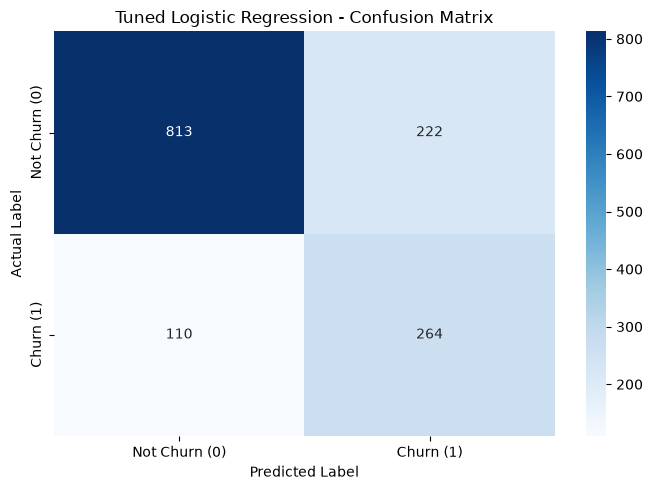

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

# Plot the matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn (0)", "Churn (1)"],
    yticklabels=["Not Churn (0)", "Churn (1)"]
)

plt.title("Tuned Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Initialize Random Forest
rf = RandomForestClassifier(
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Define hyperparameter combinations
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Set up Grid Search with cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train and search for the best parameters
grid_search.fit(X_train_final, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1-Score:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation F1-Score:
0.6333


In [77]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Retrieve the best Random Forest model
best_rf_model = grid_search.best_estimator_

# Make predictions on the test dataset
y_pred_rf_tuned = best_rf_model.predict(X_test_final)

# Calculate evaluation metrics
print("Tuned Random Forest Evaluation")
print("-" * 40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf_tuned):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Tuned Random Forest Evaluation
----------------------------------------
Accuracy:  0.7566
Precision: 0.5284
Recall:    0.7701
F1-Score:  0.6268

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1035
           1       0.53      0.77      0.63       374

    accuracy                           0.76      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.76      0.77      1409

Confusion Matrix:
[[778 257]
 [ 86 288]]


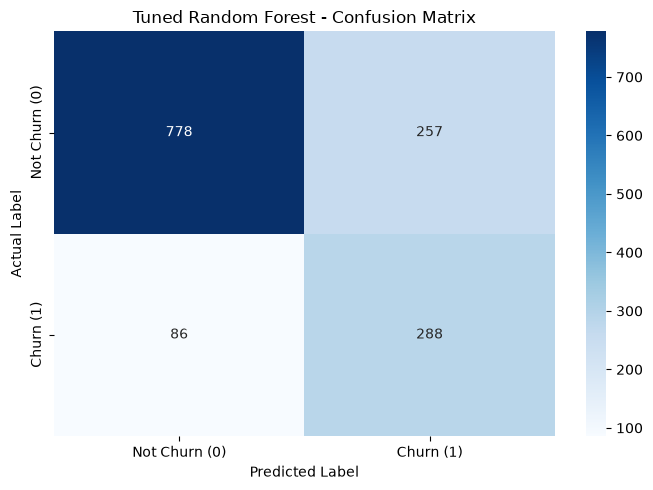

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

# Plot the matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn (0)", "Churn (1)"],
    yticklabels=["Not Churn (0)", "Churn (1)"]
)

plt.title("Tuned Random Forest - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

Top 15 Important Features:
                            Feature  Importance
                        num__tenure    0.119209
       cat__Contract_Month-to-month    0.113646
                  num__TotalCharges    0.103781
                num__MonthlyCharges    0.076107
             cat__OnlineSecurity_No    0.068417
             cat__Contract_Two year    0.062453
                cat__TechSupport_No    0.054106
   cat__InternetService_Fiber optic    0.049678
cat__PaymentMethod_Electronic check    0.040559
             cat__Contract_One year    0.019389
               cat__OnlineBackup_No    0.018398
           cat__InternetService_DSL    0.016375
            cat__OnlineSecurity_Yes    0.014002
           cat__PaperlessBilling_No    0.012658
               cat__TechSupport_Yes    0.012201


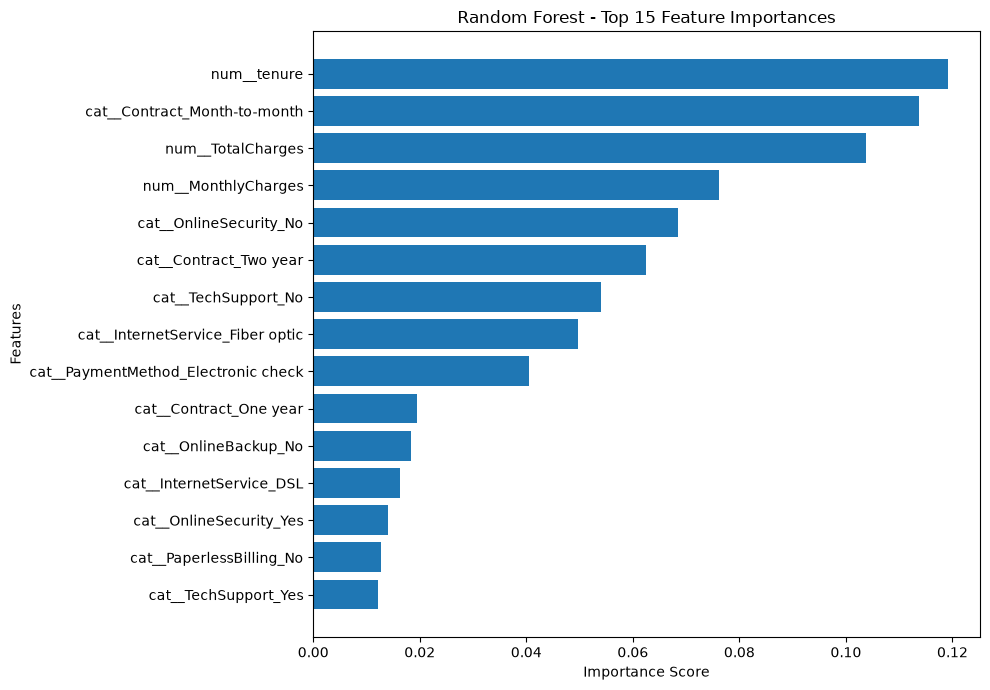

In [79]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature names from the preprocessing step
feature_names = preprocessor.get_feature_names_out()

# Extract feature importance scores
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": best_rf_model.feature_importances_
})

# Sort features by importance
rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the top 15 features
print("Top 15 Important Features:")
print(rf_importance.head(15).to_string(index=False))

# Plot the top 15 features
top_features = rf_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Random Forest - Top 15 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()